In [13]:
%matplotlib inline

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [15]:
print("all libraries are loaded")

all libraries are loaded


In [16]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
print(df.shape)

(7043, 21)


In [18]:
print(df.info())
print("/ncolumn names:",df.columns)
print("/ndata types:",df.dtypes)
print("/nmissing values:",df.isnull().sum())
print("/nunique values:",df.nunique)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Null values in TotalCharges:",df['TotalCharges'].isnull().sum())

Null values in TotalCharges: 11


In [20]:
df.dropna(inplace=True)
print("Cleanes space:",df.shape)

Cleanes space: (7032, 21)


In [21]:
print(df['Churn'].value_counts())
print("Churn rate",round(df['Churn']))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn rate 0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7032, dtype: object


In [22]:
print(df['Churn'].value_counts())
print("Churn rate",round(df['Churn'].value_counts(normalize=True)['Yes']*100,2),'%')

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn rate 26.58 %


In [24]:
df.groupby['Contract']("Churn").value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1306
                Yes       166
Two year        No       1637
                Yes        48
Name: count, dtype: int64

In [25]:
df.groupby('Churn')['tenure'].mean()


,tenure
Churn,
No,37.650010
Yes,17.979133


In [33]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


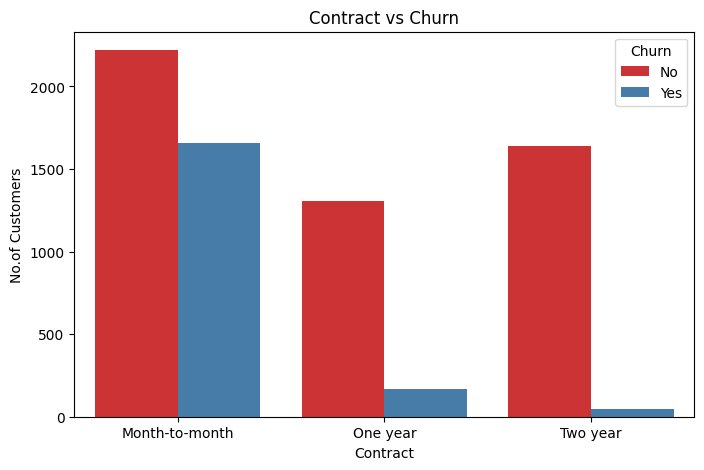

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn',data=df,palette='Set1')
plt.title('Contract vs Churn')
plt.xlabel('Contract')
plt.ylabel('No.of Customers')
plt.show()

/tmp/ipykernel_1950/2705847484.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y='tenure',data=df,palette='Set2')


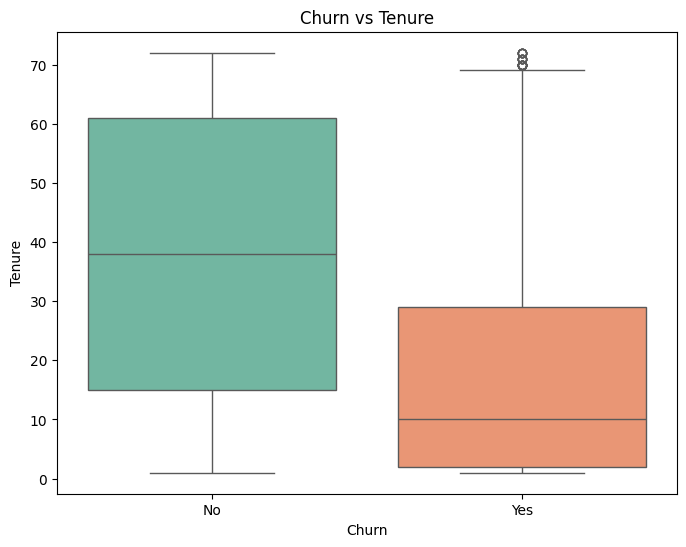

In [37]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn',y='tenure',data=df,palette='Set2')
plt.title('Churn vs Tenure')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

/tmp/ipykernel_1950/1964882103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y='MonthlyCharges',data=df,palette='Set2')


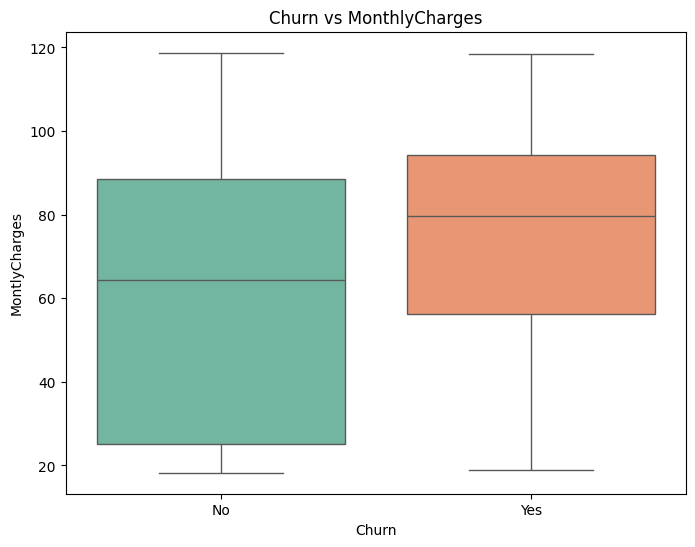

In [38]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df,palette='Set2')
plt.title('Churn vs MonthlyCharges')
plt.xlabel('Churn')
plt.ylabel('MontlyCharges')
plt.show()